# Episode Plausibility

Visual checks on individual episodes: obs-action alignment, z-axis insertion dynamics, full 6D wrench, phase structure.
Run this on a handful of episodes before bulk training.

In [1]:
import numpy as np
import h5py
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True

In [2]:
REPO_ROOT = Path().resolve().parent
DATASET_DIR = REPO_ROOT / "dataset"

datasets = sorted([d for d in DATASET_DIR.iterdir() if d.is_dir() and (d / "dataset_index.yaml").exists()])
print("Found datasets:")
for i, d in enumerate(datasets):
    print(f"  [{i}] {d.name}")

# Pick one — change index if you have multiple
DATA_DIR = datasets[-1]  # latest by name, since you use date suffixes
print(f"\nUsing: {DATA_DIR.name}")

with open(DATA_DIR / "dataset_index.yaml", "r") as f:
    index = yaml.safe_load(f)

successful = [e for e in index if e["success"]]
failed = [e for e in index if not e["success"]]
print(f"Total: {len(index)} | Success: {len(successful)} ({100*len(successful)/len(index):.1f}%) | Failed: {len(failed)}")

Found datasets:
  [0] rect_small_tight_200Hz_2026-03-29
  [1] rect_small_tight_200Hz_2026-03-31
  [2] rect_small_tight_200Hz_2026-04-05
  [3] rect_small_tight_200hz_2026-04-06

Using: rect_small_tight_200hz_2026-04-06
Total: 3827 | Success: 2486 (65.0%) | Failed: 1341


In [3]:
def load_episode(path):
    data = {}
    with h5py.File(path, 'r') as f:
        for group in f.keys():
            if isinstance(f[group], h5py.Group):
                for k in f[group].keys():
                    data[f'{group}/{k}'] = f[group][k][()]
    return data

def get_time(ep):
    ts = ep['obs/timestamps']
    return ts - ts[0]

## Pick an episode to inspect
Change `EP_IDX` to look at different episodes. Try a few successful and one failed.

In [4]:
EP_IDX = 0  # index into successful list
entry = successful[EP_IDX]
ep = load_episode(DATA_DIR / entry['path'])
t = get_time(ep)

print(f"Episode {entry['episode_id']}: {len(t)} steps, {t[-1]:.2f}s, success={entry['success']}")
print(f"Hole pos: {entry['hole_pos']}")
print(f"Shapes: f_ext={ep['obs/f_ext'].shape}, f_internal={ep['obs/f_internal'].shape}, "
      f"ee_vel={ep['obs/ee_velocity'].shape}, Fff={ep['action/Fff'].shape}")

Episode 0: 1668 steps, 8.33s, success=True
Hole pos: [0.5008101559272469, -0.001140318844632486, 0.425]
Shapes: f_ext=(1668, 6), f_internal=(1668, 6), ee_vel=(1668, 6), Fff=(1668, 6)


## 1. Obs-Action Alignment
Fff XY (commanded wiggle) vs f_ext XY (contact response).
The sinusoidal command should visibly lead the response — force leads, reaction follows with slight lag.
If perfectly synchronized or off by one step, recording timing is wrong.

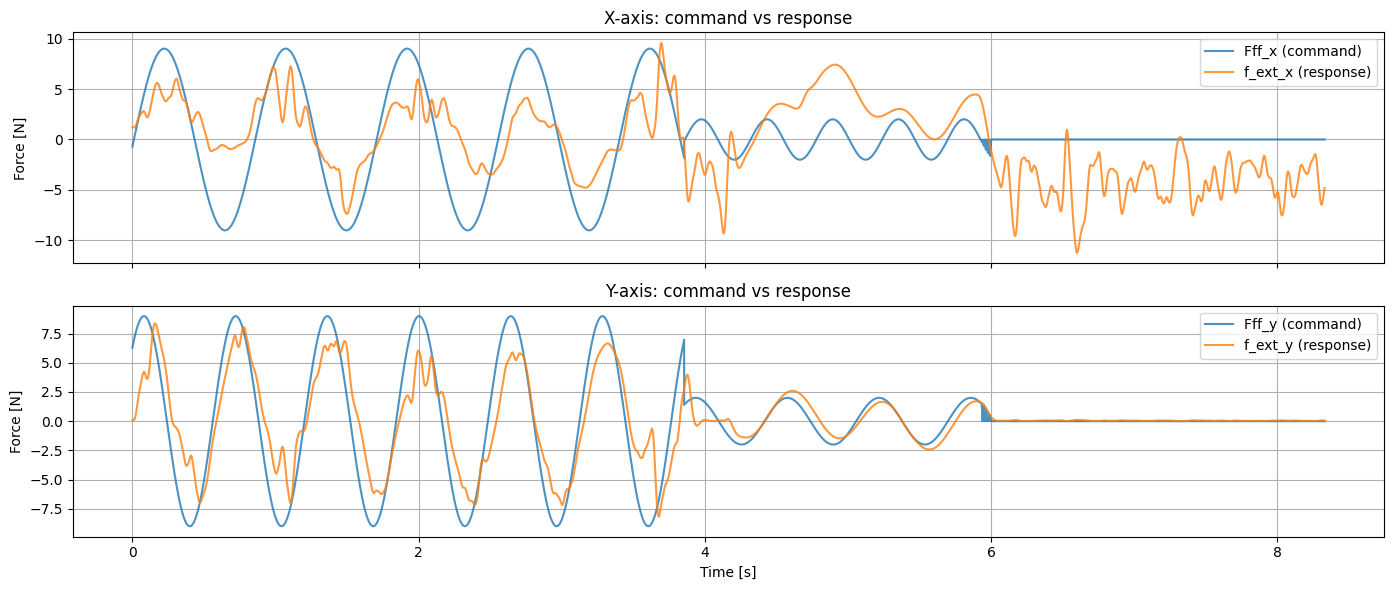

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(t, ep['action/Fff'][:, 0], label='Fff_x (command)', alpha=0.8)
axes[0].plot(t, ep['obs/f_ext'][:, 0], label='f_ext_x (response)', alpha=0.8)
axes[0].set_ylabel('Force [N]')
axes[0].set_title('X-axis: command vs response')
axes[0].legend()

axes[1].plot(t, ep['action/Fff'][:, 1], label='Fff_y (command)', alpha=0.8)
axes[1].plot(t, ep['obs/f_ext'][:, 1], label='f_ext_y (response)', alpha=0.8)
axes[1].set_ylabel('Force [N]')
axes[1].set_xlabel('Time [s]')
axes[1].set_title('Y-axis: command vs response')
axes[1].legend()

plt.tight_layout()

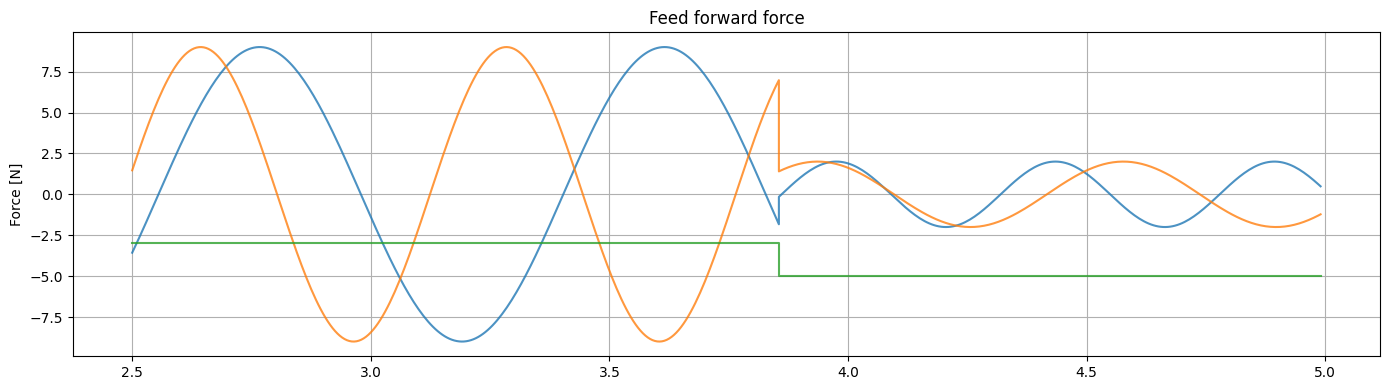

In [23]:
start, stop = 500, 1000
plt.plot(t[start:stop], ep['action/Fff'][start:stop, 0:3], label='Fff_x (command)', alpha=0.8)
plt.ylabel('Force [N]')
plt.title('Feed forward force')

plt.tight_layout()

### Zoom into a 1-second window to check lag structure

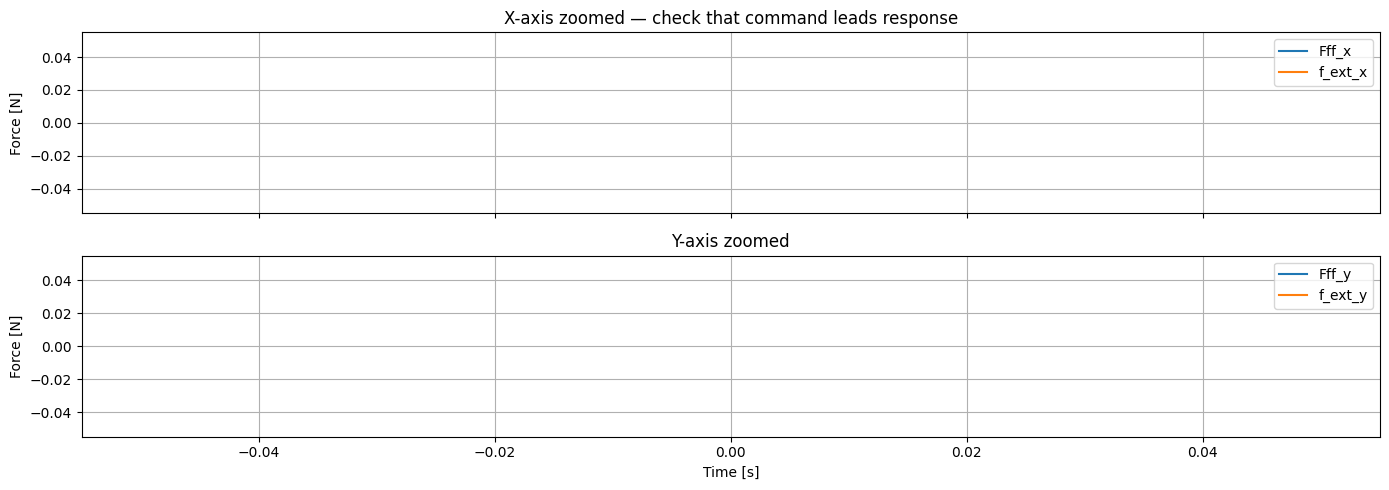

In [17]:
t_start, t_end = 15.0, 16.0 
mask = (t >= t_start) & (t <= t_end)

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(t[mask], ep['action/Fff'][mask, 0], label='Fff_x', linewidth=1.5)
axes[0].plot(t[mask], ep['obs/f_ext'][mask, 0], label='f_ext_x', linewidth=1.5)
axes[0].set_ylabel('Force [N]')
axes[0].set_title('X-axis zoomed — check that command leads response')
axes[0].legend()

axes[1].plot(t[mask], ep['action/Fff'][mask, 1], label='Fff_y', linewidth=1.5)
axes[1].plot(t[mask], ep['obs/f_ext'][mask, 1], label='f_ext_y', linewidth=1.5)
axes[1].set_ylabel('Force [N]')
axes[1].set_xlabel('Time [s]')
axes[1].set_title('Y-axis zoomed')
axes[1].legend()

plt.tight_layout()

## 2. Z-Axis Insertion Dynamics
Three things should be visible:
- Fff_z is roughly constant (downward press force, ~-5N from your config)
- f_ext_z shows the reaction force building during contact
- If you have peg_tip_pos in debug, z should decrease as the peg enters the hole

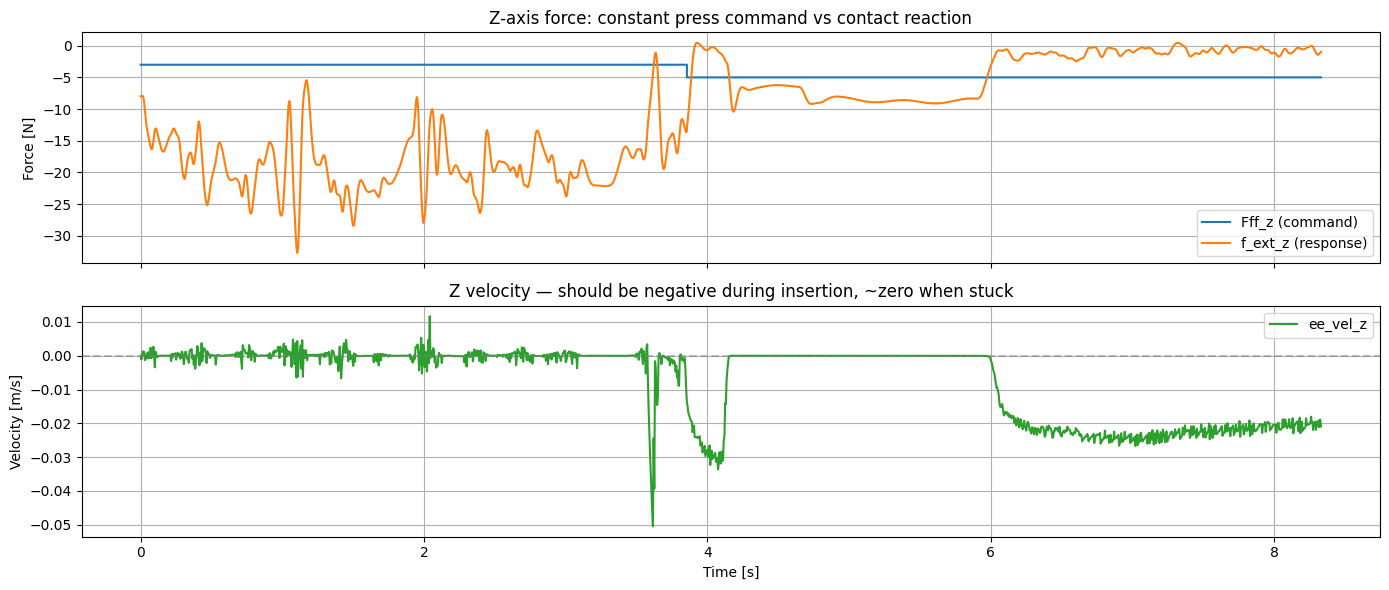

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(t, ep['action/Fff'][:, 2], label='Fff_z (command)', color='C0')
axes[0].plot(t, ep['obs/f_ext'][:, 2], label='f_ext_z (response)', color='C1')
axes[0].set_ylabel('Force [N]')
axes[0].set_title('Z-axis force: constant press command vs contact reaction')
axes[0].legend()

axes[1].plot(t, ep['obs/ee_velocity'][:, 2] if ep['obs/ee_velocity'].shape[1] > 2 else ep['obs/ee_velocity'][:, -1],
             label='ee_vel_z', color='C2')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Velocity [m/s]')
axes[1].set_xlabel('Time [s]')
axes[1].set_title('Z velocity — should be negative during insertion, ~zero when stuck')
axes[1].legend()

plt.tight_layout()

## 3. Full 6D Wrench — All Channels
Check for dead channels (flat lines), NaN/inf spikes, or anything physically implausible.
Torque channels (indices 3-5) should show rotational forces during wiggle.

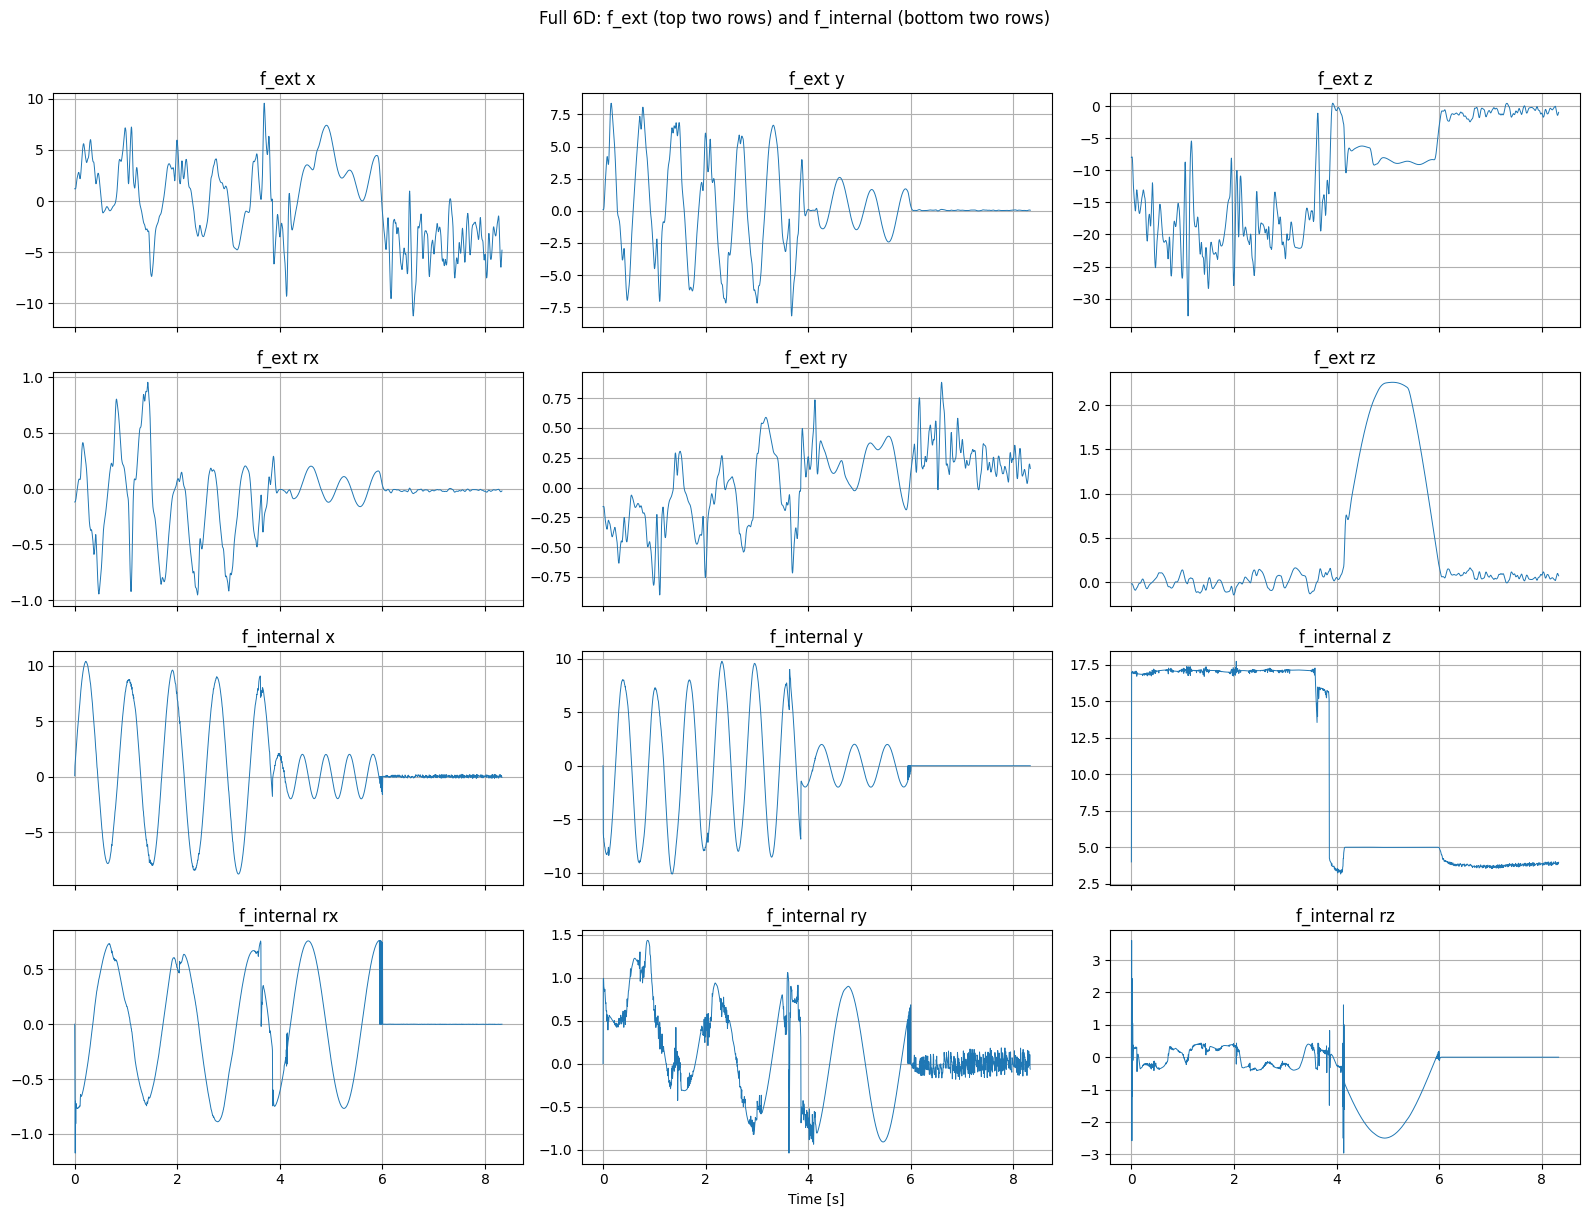

In [8]:
labels_force = ['x', 'y', 'z']
labels_torque = ['rx', 'ry', 'rz']

fig, axes = plt.subplots(4, 3, figsize=(16, 12), sharex=True)

for i in range(3):
    axes[0, i].plot(t, ep['obs/f_ext'][:, i], linewidth=0.7)
    axes[0, i].set_title(f'f_ext {labels_force[i]}')
    
    axes[1, i].plot(t, ep['obs/f_ext'][:, 3+i], linewidth=0.7)
    axes[1, i].set_title(f'f_ext {labels_torque[i]}')
    
    axes[2, i].plot(t, ep['obs/f_internal'][:, i], linewidth=0.7)
    axes[2, i].set_title(f'f_internal {labels_force[i]}')
    
    axes[3, i].plot(t, ep['obs/f_internal'][:, 3+i], linewidth=0.7)
    axes[3, i].set_title(f'f_internal {labels_torque[i]}')

axes[3, 1].set_xlabel('Time [s]')
fig.suptitle('Full 6D: f_ext (top two rows) and f_internal (bottom two rows)', y=1.01)
plt.tight_layout()

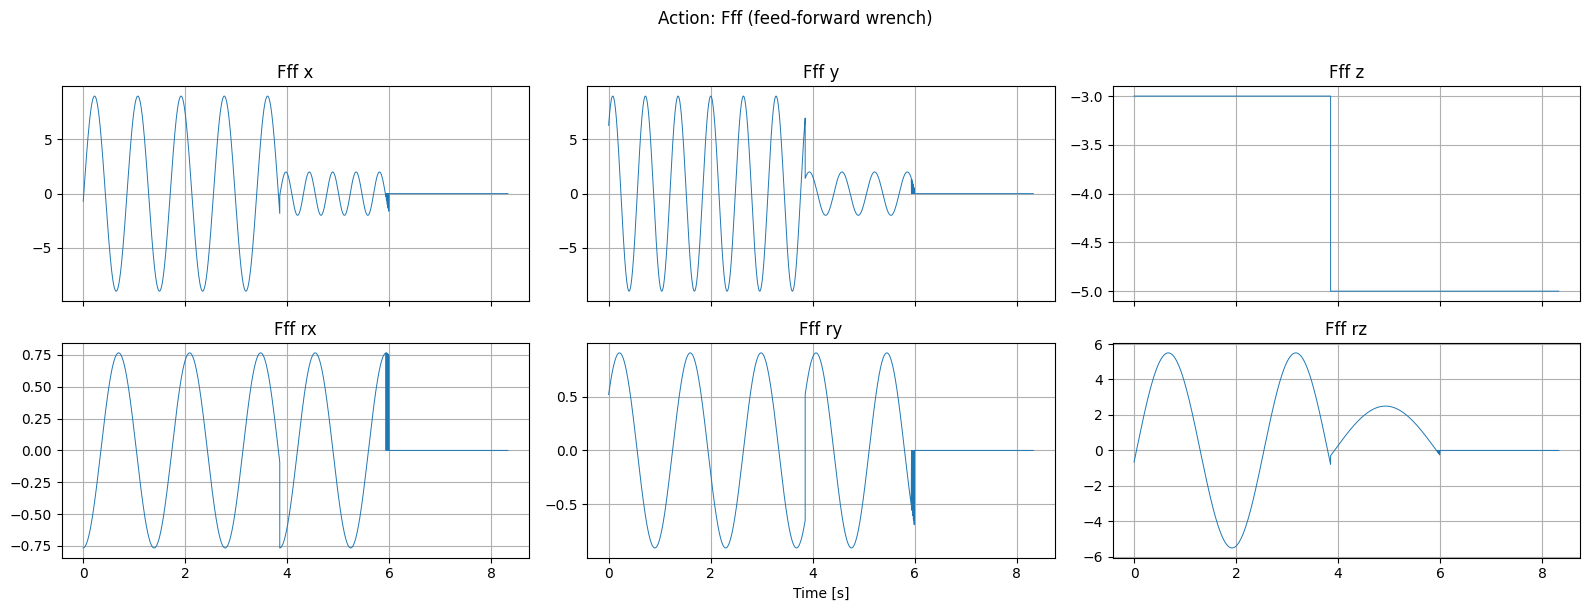

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 6), sharex=True)

for i in range(3):
    axes[0, i].plot(t, ep['action/Fff'][:, i], linewidth=0.7)
    axes[0, i].set_title(f'Fff {labels_force[i]}')
    
    axes[1, i].plot(t, ep['action/Fff'][:, 3+i], linewidth=0.7)
    axes[1, i].set_title(f'Fff {labels_torque[i]}')

axes[1, 1].set_xlabel('Time [s]')
fig.suptitle('Action: Fff (feed-forward wrench)', y=1.01)
plt.tight_layout()

## 4. EE Velocity — All Available Channels
Check whether you have 3D (linear only) or 6D (linear + angular).
If 3D, angular velocity is missing and obs vector is 15-dim instead of the 18-dim TacDiffusion spec.

ee_velocity shape: (1668, 6) — expecting (T, 6) for full TacDiffusion obs


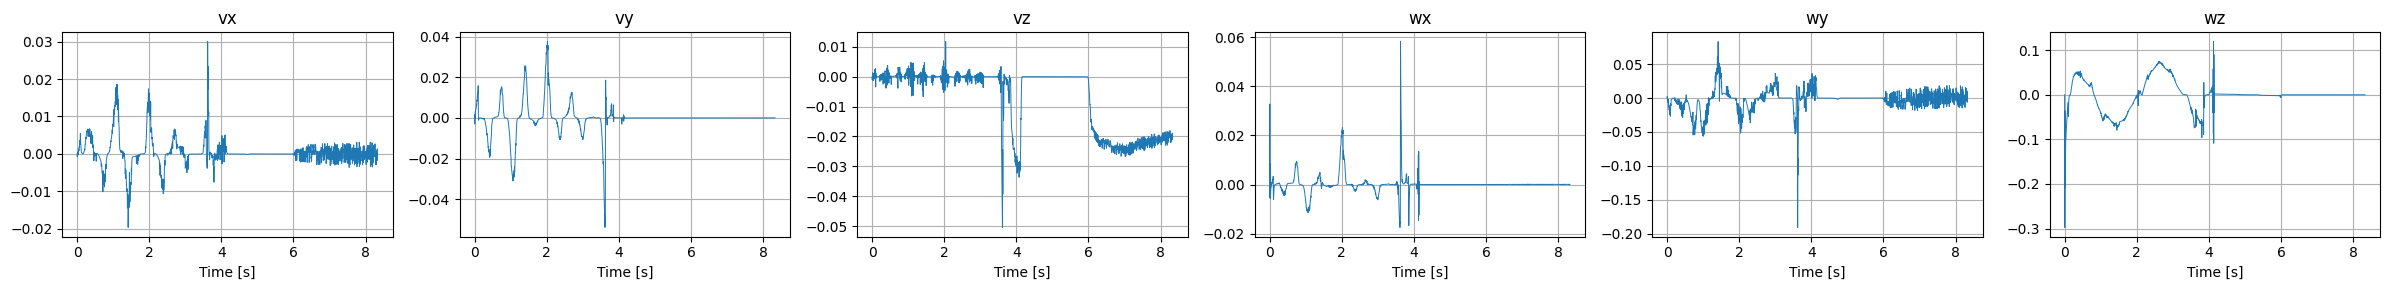

In [10]:
ee_vel = ep['obs/ee_velocity']
print(f'ee_velocity shape: {ee_vel.shape} — expecting (T, 6) for full TacDiffusion obs')

n_vel = ee_vel.shape[1]
vel_labels = ['vx', 'vy', 'vz', 'wx', 'wy', 'wz'][:n_vel]

fig, axes = plt.subplots(1, n_vel, figsize=(4*n_vel, 3))
if n_vel == 1:
    axes = [axes]
for i in range(n_vel):
    axes[i].plot(t, ee_vel[:, i], linewidth=0.7)
    axes[i].set_title(vel_labels[i])
    axes[i].set_xlabel('Time [s]')
plt.tight_layout()

## 5. NaN / Inf / Constant Check
Quick automated scan for data quality issues across all channels.

In [11]:
obs_all = np.concatenate([ep['obs/f_ext'], ep['obs/f_internal'], ep['obs/ee_velocity']], axis=1)
act_all = ep['action/Fff']

print('--- Observations ---')
print(f'  NaN count: {np.isnan(obs_all).sum()}')
print(f'  Inf count: {np.isinf(obs_all).sum()}')
for i in range(obs_all.shape[1]):
    std = obs_all[:, i].std()
    if std < 1e-10:
        print(f'  WARNING: obs channel {i} is constant (std={std:.2e})')

print('\n--- Actions ---')
print(f'  NaN count: {np.isnan(act_all).sum()}')
print(f'  Inf count: {np.isinf(act_all).sum()}')
for i in range(act_all.shape[1]):
    std = act_all[:, i].std()
    if std < 1e-10:
        print(f'  WARNING: action channel {i} is constant (std={std:.2e})')

--- Observations ---
  NaN count: 0
  Inf count: 0

--- Actions ---
  NaN count: 0
  Inf count: 0


## 6. Compare a Successful vs Failed Episode
Pick one of each and overlay the z-axis dynamics. 
This helps you understand what failure looks like in the data and whether failed episodes are worth excluding.

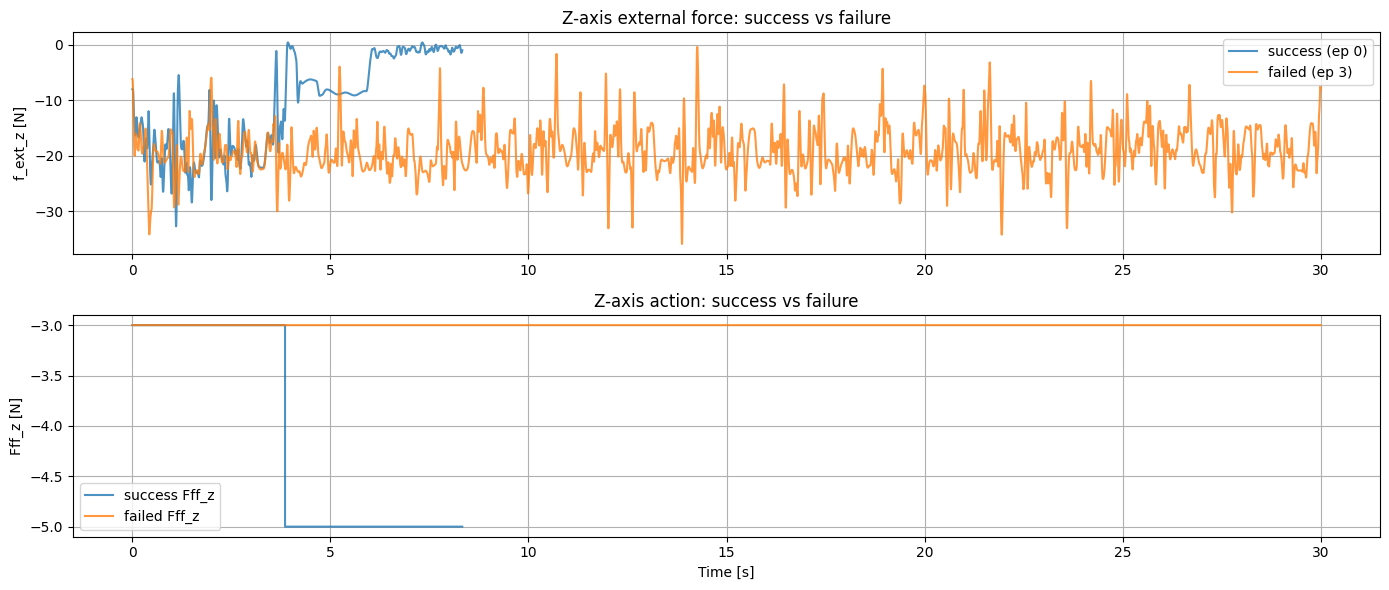

In [12]:
if len(failed) > 0:
    ep_fail = load_episode(DATA_DIR / failed[0]['path'])
    t_fail = get_time(ep_fail)

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

    axes[0].plot(t, ep['obs/f_ext'][:, 2], label=f"success (ep {entry['episode_id']})", alpha=0.8)
    axes[0].plot(t_fail, ep_fail['obs/f_ext'][:, 2], label=f"failed (ep {failed[0]['episode_id']})", alpha=0.8)
    axes[0].set_ylabel('f_ext_z [N]')
    axes[0].set_title('Z-axis external force: success vs failure')
    axes[0].legend()

    axes[1].plot(t, ep['action/Fff'][:, 2], label='success Fff_z', alpha=0.8)
    axes[1].plot(t_fail, ep_fail['action/Fff'][:, 2], label='failed Fff_z', alpha=0.8)
    axes[1].set_ylabel('Fff_z [N]')
    axes[1].set_xlabel('Time [s]')
    axes[1].set_title('Z-axis action: success vs failure')
    axes[1].legend()

    plt.tight_layout()
else:
    print('No failed episodes in dataset')